In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize,poly)
from matplotlib.pyplot import subplots
from statsmodels.stats.anova import anova_lm
import math

Boston = pd.read_csv('./data/Boston.csv')
Boston = Boston.drop(Boston.columns[0], axis=1)

y = Boston['crim']
Boston = Boston.drop('crim', axis=1)
Boston

,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [22]:
for column in Boston.columns:
    results = sm.OLS(y, pd.DataFrame({column: Boston[column], 'intercept': 1})).fit()
    print(summarize(results))

             coef  std err       t  P>|t|
zn        -0.0739    0.016  -4.594    0.0
intercept  4.4537    0.417  10.675    0.0
             coef  std err      t  P>|t|
indus      0.5098    0.051  9.991  0.000
intercept -2.0637    0.667 -3.093  0.002
             coef  std err      t  P>|t|
chas      -1.8928    1.506 -1.257  0.209
intercept  3.7444    0.396  9.453  0.000
              coef  std err       t  P>|t|
nox        31.2485    2.999  10.419    0.0
intercept -13.7199    1.699  -8.073    0.0
              coef  std err      t  P>|t|
rm         -2.6841    0.532 -5.045    0.0
intercept  20.4818    3.364  6.088    0.0
             coef  std err      t  P>|t|
age        0.1078    0.013  8.463    0.0
intercept -3.7779    0.944 -4.002    0.0
             coef  std err       t  P>|t|
dis       -1.5509    0.168  -9.213    0.0
intercept  9.4993    0.730  13.006    0.0
             coef  std err       t  P>|t|
rad        0.6179    0.034  17.998    0.0
intercept -2.2872    0.443  -5.157    0.

Практически все предикторы статистически значимы, сомнения могут быть только в отношении предиктора chas      

In [24]:
all_results = sm.OLS(y, Boston).fit()
print(summarize(all_results))

           coef  std err      t  P>|t|
zn       0.0450    0.019  2.391  0.017
indus   -0.0699    0.084 -0.835  0.404
chas    -0.8568    1.187 -0.722  0.471
nox     -4.0431    4.341 -0.931  0.352
rm       1.2173    0.528  2.306  0.022
age     -0.0033    0.018 -0.182  0.856
dis     -0.7762    0.256 -3.034  0.003
rad      0.5523    0.082  6.725  0.000
tax     -0.0023    0.005 -0.444  0.657
ptratio -0.0598    0.138 -0.433  0.665
lstat    0.1966    0.070  2.814  0.005
medv    -0.1797    0.056 -3.194  0.001


Интересно что предикторы indus   chas    nox    age      tax   ptratio имеют достаточно высокое р-значение, а значит для них мы не можем отклонить
нулевую гипотезу что Bi = 0
Остальные же предикторы имеют умеренно низкое p-значение, что позволяет посматривать в сторону отклонения такой гипотезы

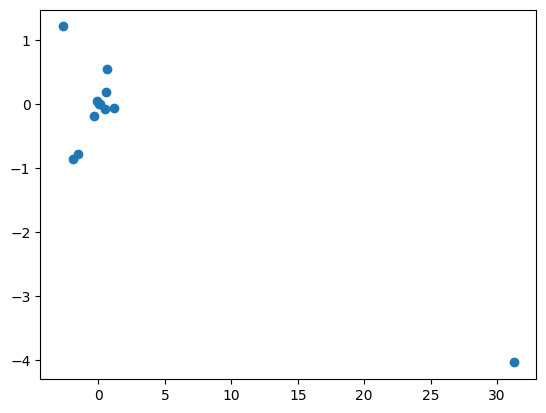

In [29]:
x_values = []
y_values = []

for column in Boston.columns:
    results = sm.OLS(y, pd.DataFrame({column: Boston[column], 'intercept': 1})).fit()
    x_values.append(results.params[column])
    y_values.append(all_results.params[column])

ax = subplots()[1]
ax.scatter(x_values, y_values);


In [31]:
for column in Boston.columns:
    results = sm.OLS(y, pd.DataFrame({column: Boston[column], 'squared': Boston[column] ** 2, 'cube': Boston[column] ** 3, 'intercept': 1})).fit()
    print(summarize(results))

               coef   std err       t  P>|t|
zn        -0.332200  0.110000  -3.025  0.003
squared    0.006500  0.004000   1.679  0.094
cube      -0.000038  0.000031  -1.203  0.230
intercept  4.846100  0.433000  11.192  0.000
             coef  std err      t  P>|t|
indus     -1.9652    0.482 -4.077   0.00
squared    0.2519    0.039  6.407   0.00
cube      -0.0070    0.001 -7.292   0.00
intercept  3.6626    1.574  2.327   0.02
             coef  std err      t  P>|t|
chas      -0.6309    0.502 -1.257  0.209
squared   -0.6309    0.502 -1.257  0.209
cube      -0.6309    0.502 -1.257  0.209
intercept  3.7444    0.396  9.453  0.000
                coef  std err      t  P>|t|
nox       -1279.3713  170.397 -7.508    0.0
squared    2248.5441  279.899  8.033    0.0
cube      -1245.7029  149.282 -8.345    0.0
intercept   233.0866   33.643  6.928    0.0
               coef  std err      t  P>|t|
rm         -39.1501   31.311 -1.250  0.212
squared      4.5509    5.010  0.908  0.364
cube        -0.1

ОЧень интересно, получается, если верить рассчитанные Т и Р значениям, то многие показатели в датафрейме Бостон имеют нелинейность по отношению
к уровню криминалитета, хотя оценки некоторых предикторов перестали быть статистически значимыми ил их квартат и куб не сильно влияю на отклик,
ну точнее исходя из р-значения мы не можем говорить об отклонении нулевой гипотеры их нулевых коэффициентов. 